# Simple Linear regression:

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv("datasets/placement.csv")
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


Text(0, 0.5, 'package(in LPA)')

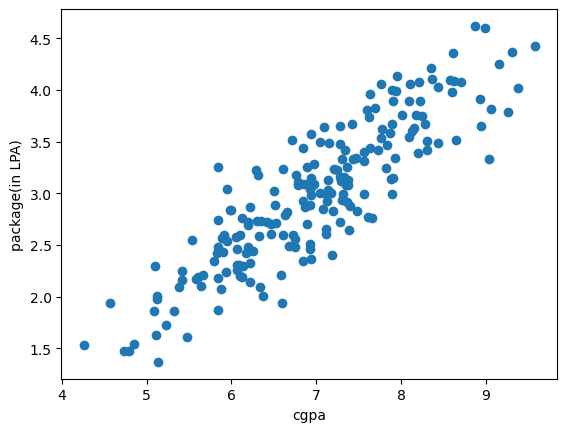

In [13]:
plt.scatter(df["cgpa"], df["package"])
plt.xlabel("cgpa")
plt.ylabel("package(in LPA)")

**step1: differentiate input column(x) and output column(y):**

In [14]:
x = df.iloc[:,0:1]   # saare rows and 1st column
y = df.iloc[:,-1]

**step2: we split data into 2 parts: "train set" and "test set" so hum kuch data hide kr lete hai jis se age questions puche jaa skein to make sure ki answers correct aa rhe hai yn nhi because humnein answer pata hoga already**

In [16]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=2)

In [17]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()     # make object

In [18]:
#train model now:

lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
x_test.head()

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57


In [21]:
y_test.head()

112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
Name: package, dtype: float64

**now check prediction by giving data to check ki model perfect yn accurate hai bhi ynn nhi. for ex: 112 vaale ka package check krna hai ki vo kitna aaya and compare it with original package i.e. 4.19 LPA**

In [27]:
lr.predict(x_test.iloc[0].values.reshape(1,1))

C:\Users\adity\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

**3.89 but hamein 4.10 chahiye tha to next row ka check krenge**

In [29]:
lr.predict(x_test.iloc[1].values.reshape(1,1))

C:\Users\adity\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.09324469])

**step3: best fit line draw krni hai for training set**

Text(0, 0.5, 'package(in LPA)')

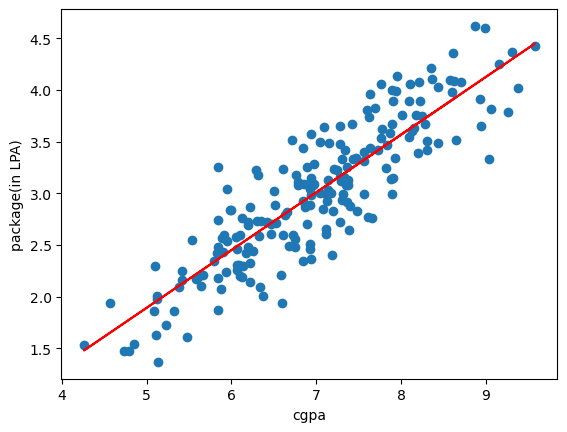

In [34]:
plt.scatter(df["cgpa"], df["package"])
plt.plot(x_train,lr.predict(x_train), color="red")
plt.xlabel("cgpa")
plt.ylabel("package(in LPA)")

**step4: find slope(m) and y intercept(c):** 

because m is like "weightage": ki x(in this case cgpa) kitna depend krta hai for output (in this case package in LPA)
if m increases package is also increase and vice versa and intercept ki if x=0 tab bhi y ki koi value ho

In [36]:
m = lr.coef_
m

array([0.55795197])

In [37]:
c = lr.intercept_
c

np.float64(-0.8961119222429144)

In [40]:
# so for y = m*x+c

m*5.8+c    # for third row i.e. 5.8 and compare it woth original value i.e. 2.08 lPA

array([2.34000952])

# Now we make custom class to test and train predictions just like we previously use sklearn library to train linear regression model:

In [85]:
class MeraLr:
    def __init__(self):
        self.m = None     # slope 
        self.c = None     # y intercept

    def fit(self, x_train, y_train):          # fit name ka function jo x_train and y_train as parameter leta hai and find m and c from formula
        num = 0
        den = 0
        for i in range(x_train.shape[0]):
            num = num + ((x_train[i] - x_train.mean())*(y_train[i] - y_train.mean()))
            den = den + ((x_train[i] - x_train.mean())*(x_train[i] - x_train.mean()))
            
        self.m = num/den
        self.c = y_train.mean() - (self.m * x_train.mean())
        
        print("slope is:" , self.m)
        print("intercept is:" , self.c)
        
    def predict(self, x_test):
        print("your x_test is:", x_test)
        a = self.m * x_test + self.c       # y = m*x + c
        print("your value for this x is:", a)

In [86]:
import numpy as np
import pandas as pd

In [87]:
df = pd.read_csv("datasets/placement.csv")

In [88]:
# now extract x and y as numpy arrays:

x = df.iloc[:,0].values
y = df.iloc[:,1].values

In [89]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 2)

In [90]:
lr = MeraLr()     # object from meralr class

In [91]:
lr.fit(x_train, y_train)

slope is: 0.5579519734250721
intercept is: -0.8961119222429152


In [92]:
lr.predict(x_test[0])

your x_test is: 8.58
your value for this x is: 3.891116009744203


# Regression metrics:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [95]:
df = pd.read_csv("datasets/placement.csv")
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'package(in LPA)')

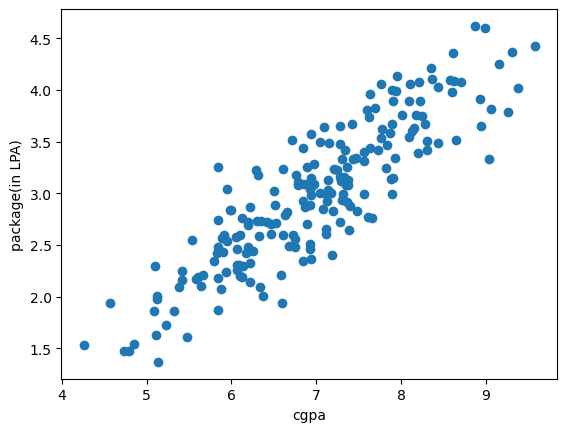

In [96]:
plt.scatter(df["cgpa"], df["package"])
plt.xlabel("cgpa")
plt.ylabel("package(in LPA)")

In [100]:
x = df.iloc[:,0:1]   
y = df.iloc[:,-1]

In [101]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=2)

In [103]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()     # make object

In [104]:
#train model now:

lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [105]:
lr.predict(x_test.iloc[0].values.reshape(1,1))

C:\Users\adity\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

Text(0, 0.5, 'package(in LPA)')

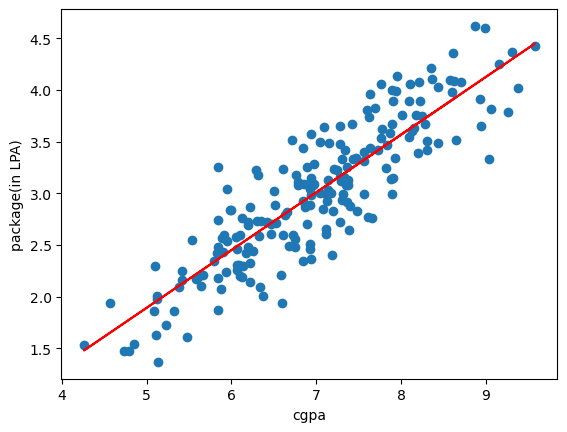

In [106]:
plt.scatter(df["cgpa"], df["package"])
plt.plot(x_train,lr.predict(x_train), color="red")
plt.xlabel("cgpa")
plt.ylabel("package(in LPA)")

In [122]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [123]:
y_pred = lr.predict(x_test)
y_pred

array([3.89111601, 3.09324469, 2.38464568, 2.57434935, 1.6537286 ,
       1.77647803, 2.07219258, 2.93143862, 3.76278706, 2.93701814,
       4.09197872, 3.51170867, 2.97049525, 2.40138424, 3.18809652,
       3.46707251, 1.94386362, 3.24389172, 2.97607477, 3.41685683,
       2.55761079, 3.16577844, 2.85890486, 3.12114229, 3.68467378,
       2.8700639 , 3.49497011, 3.34432308, 3.91901361, 1.96060218,
       3.65119666, 3.2104146 , 3.74046898, 2.7863711 , 2.78079158,
       3.27178932, 3.52844723, 2.61340599, 2.65804215, 2.71383735])

In [124]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [125]:
print("MAE is :", mean_absolute_error(y_test, y_pred))
print("MSE is :", mean_squared_error(y_test, y_pred))
print("RMSE is :", np.sqrt(mean_absolute_error(y_test, y_pred)))
print("R2 score is :", r2_score(y_test, y_pred))

MAE is : 0.2884710931878175
MSE is : 0.12129235313495527
RMSE is : 0.5370950504220063
R2 score is : 0.780730147510384


In [126]:
# Adjusted r2 score:

r2 = r2_score(y_test, y_pred)

In [115]:
x_test.shape   # to get n = tatal rows

(40, 1)

In [130]:
r2_adjusted = 1- ((1-r2)*(40-1)/(40-1-1))        # k = 1 only 1 input as cgpa
print("r2_adjusted is : ", r2_adjusted)

r2_adjusted is :  0.7749598882343415


# 1. Case1: when irrelevant column added:

In [131]:
newdf1 = df.copy()
newdf1["random_feature"] = np.random.random(200)
newdf1 = newdf1[["cgpa", "random_feature", "package"]]
newdf1.head()

,cgpa,random_feature,package
0,6.89,0.171337,3.26
1,5.12,0.873787,1.98
2,7.82,0.931757,3.25
3,7.42,0.365216,3.67
4,6.94,0.574125,3.57


Text(0, 0.5, 'package in LPA')

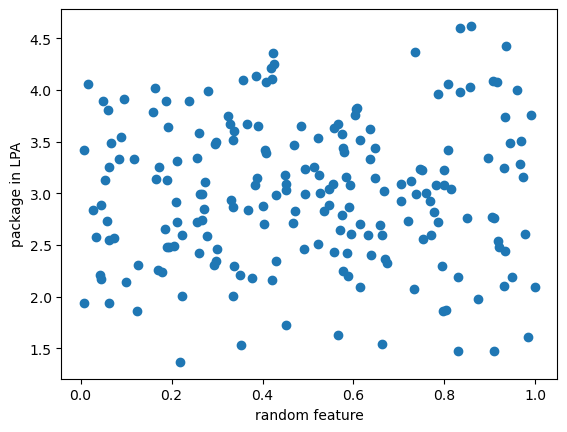

In [132]:
plt.scatter(newdf1["random_feature"], newdf1["package"])
plt.xlabel("random feature")
plt.ylabel("package in LPA")

In [147]:
x = newdf1.iloc[:,0:2]   
y = newdf1.iloc[:,-1]

In [148]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=2)

In [149]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()     # make object

In [150]:
#train model now:

lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [151]:
lr.predict(x_test)

array([3.89569327, 3.07749738, 2.37651854, 2.56821549, 1.66930869,
       1.7651543 , 2.06192728, 2.92412409, 3.76523686, 2.94266767,
       4.09529845, 3.49526154, 2.96871184, 2.39569898, 3.19617489,
       3.4516116 , 1.9572171 , 3.24836986, 2.96997969, 3.43383213,
       2.56827446, 3.1660949 , 2.86853037, 3.1219363 , 3.66970655,
       2.86103967, 3.50303948, 3.35943383, 3.90427119, 1.96653332,
       3.64882912, 3.22036722, 3.72364387, 2.80352116, 2.78593437,
       3.28009373, 3.51418966, 2.60285168, 2.66770104, 2.71044876])

In [152]:
print("R2 score is :", r2_score(y_test, y_pred))

R2 score is : 0.780730147510384


**now compare this with above r2 score and find adjusted r2 score**

In [153]:
r2_adjusted = 1- ((1-r2)*(40-1)/(40-1-2))        # k = 2 as 2 inputs are there i.e cgpa and random_feature and compare it with above r2 adjusted 
print("r2_adjusted is : ", r2_adjusted)

r2_adjusted is :  0.7688777230514858


# case 2: when relevant column is added:

In [154]:
newdf2 = df.copy()
newdf2["iq"] = newdf2["package"] + (np.random.randint(-12,12,200)/10)
newdf2 = newdf2[["cgpa", "iq", "package"]]
newdf2.head()

,cgpa,iq,package
0,6.89,3.56,3.26
1,5.12,1.38,1.98
2,7.82,2.85,3.25
3,7.42,2.87,3.67
4,6.94,2.67,3.57


Text(0, 0.5, 'package in LPA')

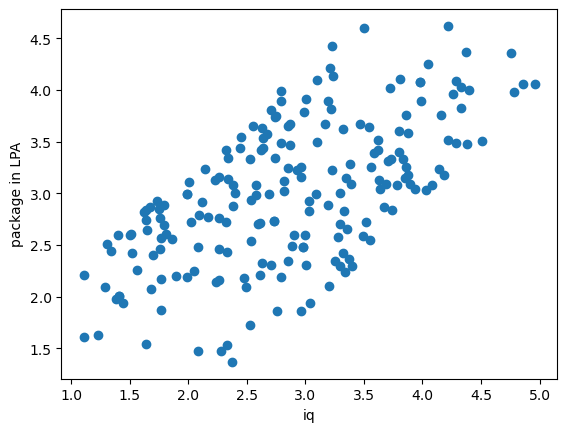

In [155]:
plt.scatter(newdf2["iq"], newdf2["package"])
plt.xlabel("iq")
plt.ylabel("package in LPA")

In [156]:
x = newdf2.iloc[:,0:2]   
y = newdf2.iloc[:,-1]

In [157]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=2)

In [158]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()     # make object

In [161]:
#train model now:

lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [162]:
lr.predict(x_test)

array([3.80294825, 3.36412979, 2.22760169, 2.5830418 , 1.55470475,
       1.78984692, 2.18080392, 3.04269038, 3.71579105, 3.10447996,
       3.92351781, 3.74379479, 2.75017145, 2.18486608, 3.20071163,
       3.39000672, 2.11197653, 3.20354033, 3.07672502, 3.23919305,
       2.64003393, 3.07167877, 2.59583888, 3.19242923, 3.80592391,
       2.67868512, 3.62359872, 3.25669685, 4.0691266 , 1.81058686,
       3.50239574, 3.02221092, 3.96150107, 2.84755698, 2.7552177 ,
       3.20088139, 3.33853618, 2.67748562, 2.40602335, 2.47402473])

In [163]:
print("R2 score is :", r2_score(y_test, y_pred))

R2 score is : 0.780730147510384


In [164]:
r2_adjusted = 1- ((1-r2)*(40-1)/(40-1-2))        # k = 2 as 2 inputs are there i.e cgpa and random_feature and compare it with above r2 adjusted 
print("r2_adjusted is : ", r2_adjusted)

r2_adjusted is :  0.7688777230514858
